# Week 4

In [25]:
import numpy as np
import sys
sys.path.append('..')
from CV_functions import box3d, Pi, PiInv, projectpoints, CrossOp

f = 1000
width = 1920
height = 1080
K = np.array([
    [f, 0, width/2],
    [0, f, height/2],
    [0, 0, 1]
])
R = np.array([
    [np.sqrt(1/2), -np.sqrt(1/2), 0],
    [np.sqrt(1/2), np.sqrt(1/2), 0],
    [0, 0, 1]
])
t = np.array([
    [0], 
    [0], 
    [10]
])

### Ex 4.1

In [26]:
P = K @ np.hstack((R, t))
Q000 = np.array([[0], [0], [0]])
Q001 = np.array([[0], [0], [1]])
Q010 = np.array([[0], [1], [0]])
Q011 = np.array([[0], [1], [1]])
Q100 = np.array([[1], [0], [0]])
Q101 = np.array([[1], [0], [1]])
Q110 = np.array([[1], [1], [0]])
Q111 = np.array([[1], [1], [1]])

q000 = Pi(P @ PiInv(Q000))
q001 = Pi(P @ PiInv(Q001))
q010 = Pi(P @ PiInv(Q010))
q011 = Pi(P @ PiInv(Q011))
q100 = Pi(P @ PiInv(Q100))
q101 = Pi(P @ PiInv(Q101))
q110 = Pi(P @ PiInv(Q110))
q111 = Pi(P @ PiInv(Q111))

print(q000)
print(q001)
print(q010)
print(q011)
print(q100)
print(q101)
print(q110)
print(q111)

[[960.]
 [540.]]
[[960.]
 [540.]]
[[889.28932188]
 [610.71067812]]
[[895.71756535]
 [604.28243465]]
[[1030.71067812]
 [ 610.71067812]]
[[1024.28243465]
 [ 604.28243465]]
[[960.        ]
 [681.42135624]]
[[960.        ]
 [668.56486931]]


### Ex 4.2

In [27]:
def pest(Q, q):
    """
    Estimate the projection matrix P using the DLT (unnormalized).
    Q: (3, n) array of 3D points (non-homogeneous)
    q: (2, n) array of 2D pixel points (non-homogeneous)
    Returns: P_est (3,4)
    """
    n = Q.shape[1]
    B_list = []
    for i in range(n):
        Xi, Yi, Zi = Q[:, i]
        xi, yi = q[:, i]
        Bi = np.array([
            [0,    -Xi,  Xi*yi,   0,   -Yi,  Yi*yi,   0,   -Zi,  Zi*yi,   0,   -1,  yi],
            [Xi,    0,  -Xi*xi,  Yi,    0,  -Yi*xi,  Zi,    0,  -Zi*xi,   1,    0, -xi],
            [-Xi*yi, Xi*xi, 0, -Yi*yi, Yi*xi, 0, -Zi*yi, Zi*xi, 0, -yi,  xi,   0]
        ])
        B_list.append(Bi)

    B = np.vstack(B_list)  # (3n, 12)

    # 0 = B @ flatten(P^T): solve via SVD, take smallest singular vector
    _, _, Vt = np.linalg.svd(B)
    v = Vt[-1]

    PT = v.reshape(4, 3)  # rows: [P11,P21,P31], [P12,P22,P32], [P13,P23,P33], [P14,P24,P34]
    P_est = PT.T           # (3,4)
    return P_est

### Ex 4.3

In [28]:
def checkerboard_points(n, m):
    Q = []
    for i in range(n):
        for j in range(m):
            Q.append([i-(n-1)/2, 
                      j-(m-1)/2, 
                      0])
    return np.array(Q).T  # (3, n*m)

### Ex 4.4

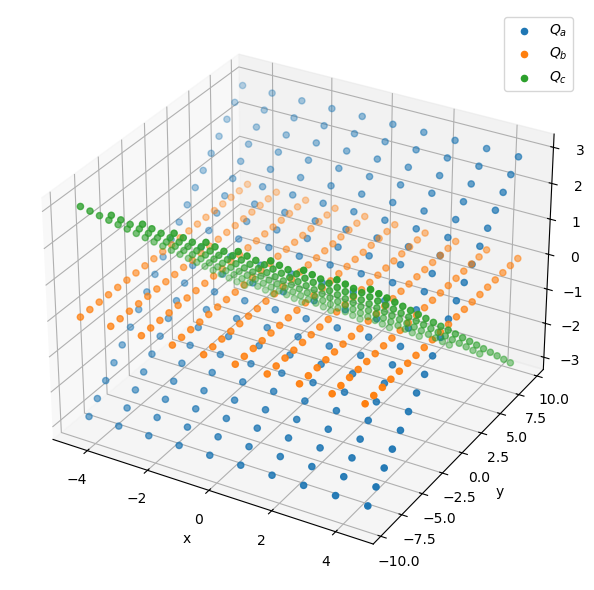

In [29]:
from scipy.spatial.transform import Rotation
import matplotlib.pyplot as plt

R = lambda theta_x, theta_y, theta_z: Rotation.from_euler('xyz', [theta_x, theta_y, theta_z]).as_matrix()

Q_Omega = checkerboard_points(10, 20)
Q_a = R(np.pi/10, 0, 0) @ Q_Omega
Q_b = R(0, 0, 0) @ Q_Omega
Q_c = R(-np.pi/10, 0, 0) @ Q_Omega

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection='3d')
 
ax.scatter(Q_a[0], Q_a[1], Q_a[2], label='$Q_a$')
ax.scatter(Q_b[0], Q_b[1], Q_b[2], label='$Q_b$')
ax.scatter(Q_c[0], Q_c[1], Q_c[2], label='$Q_c$')
 
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.legend()
plt.tight_layout()
plt.show()  # click and drag in the window to rotate


### Ex 4.5

In [30]:
def normalize2d(p):
    '''
    p: 2xn array of inhomogeneous 2D points
    Returns T (3x3 homogeneous transform) such that q_ih = T @ p_ih 
    has mean [0,0] and std [1,1]
    '''
    mu = p.mean(axis=1)      # [mu_x, mu_y]
    sigma = p.std(axis=1)    # [sigma_x, sigma_y]

    T_inv = np.array([
        [sigma[0], 0,          mu[0]],
        [0,          sigma[1], mu[1]],
        [0,          0,          1]
    ])
    return np.linalg.inv(T_inv) # Returns T

def hest(q1, q2, normalize=True):
    '''
    q1, q2: 2xn arrays of corresponding inhomogeneous points (q1 = H @ q2)
    '''
    if normalize:
        T1 = normalize2d(q1)
        T2 = normalize2d(q2)
        q1 = Pi(T1 @ PiInv(q1))
        q2 = Pi(T2 @ PiInv(q2))

    n = q1.shape[1]
    Bs = []
    for i in range(n):
        q1h = PiInv(q1[:, i:i+1])
        q2h = PiInv(q2[:, i:i+1])
        Bi = np.kron(q2h.T, CrossOp(q1h))
        Bs.append(Bi)
    B = np.vstack(Bs)

    U, S, Vt = np.linalg.svd(B)
    v = Vt[-1, :]
    Hg = v.reshape(3, 3, order='F')

    if normalize:
        Hg = np.linalg.inv(T1) @ Hg @ T2

    return Hg

def estimateHomographies(Q_omega, qs):
    Q_omega_tilde = Q_omega[:2, :]  # inhomogeneous (2, n) — just drop z
    return [hest(q, Q_omega_tilde) for q in qs]

In [31]:
q_a = Pi(P @ PiInv(Q_a))
q_b = Pi(P @ PiInv(Q_b))
q_c = Pi(P @ PiInv(Q_c))

Hs = estimateHomographies(Q_Omega, [q_a, q_b, q_c])
Q_omega_tilde_h = PiInv(Q_Omega[:2, :])

for name, H, q_true in zip(['a', 'b', 'c'], Hs, [q_a, q_b, q_c]):
    q_check = Pi(H @ Q_omega_tilde_h)
    err = np.sqrt(np.mean(np.sum((q_check - q_true)**2, axis=0)))
    print(f"H_{name} reprojection RMSE: {err:.3e}")

H_a reprojection RMSE: 5.216e-13
H_b reprojection RMSE: 3.254e-13
H_c reprojection RMSE: 5.753e-13


### Ex 4.6

In [32]:
def v_pq(H, p, q):
    """
    v_pq for the Zhang constraint, using 1-indexed column selection
    (p, q in {1, 2, 3}), built from columns h_p, h_q of H.
    """
    hp = H[:, p - 1]
    hq = H[:, q - 1]
    return np.array([
        hp[0]*hq[0],
        hp[0]*hq[1] + hp[1]*hq[0],
        hp[1]*hq[1],
        hp[2]*hq[0] + hp[0]*hq[2],
        hp[2]*hq[1] + hp[1]*hq[2],
        hp[2]*hq[2]
    ])

def estimate_b(Hs):
    """
    Hs: list of homographies (3x3).
    Returns b = [B11, B12, B22, B13, B23, B33] (up to scale).
    """
    V = []
    for H in Hs:
        v12 = v_pq(H, 1, 2)
        v11 = v_pq(H, 1, 1)
        v22 = v_pq(H, 2, 2)
        V.append(v12)
        V.append(v11 - v22)
    V = np.array(V)  # (2*len(Hs), 6)

    _, _, Vt = np.linalg.svd(V)
    b = Vt[-1, :]
    return b

B_true = np.linalg.inv(K.T) @ np.linalg.inv(K)
b_true = np.array([B_true[0, 0], B_true[0, 1], B_true[1, 1], B_true[0, 2], B_true[1, 2], B_true[2, 2]])


In [33]:
b = estimate_b(Hs)

B_true = np.linalg.inv(K.T) @ np.linalg.inv(K)
b_true = np.array([B_true[0,0], B_true[0,1], B_true[1,1],
                    B_true[0,2], B_true[1,2], B_true[2,2]])

print("b       =", b)
print("b_true  =", b_true)
print("ratio (b / b_true) =", b / b_true)

# Debug check from the exercise: v11 . b_true == h1^T B_true h1
H = Hs[0]
h1 = H[:, 0]
lhs = v_pq(H, 1, 1) @ b_true
rhs = h1 @ B_true @ h1
print(f"\nv11 . b_true = {lhs:.6f},  h1^T B_true h1 = {rhs:.6f}")

b       = [ 4.51834392e-07 -2.11758237e-22  4.51834392e-07 -4.33761016e-04
 -2.43990572e-04  9.99999876e-01]
b_true  = [ 1.0000e-06  0.0000e+00  1.0000e-06 -9.6000e-04 -5.4000e-04  2.2132e+00]
ratio (b / b_true) = [0.45183439       -inf 0.45183439 0.45183439 0.45183439 0.45183439]

v11 . b_true = 0.003424,  h1^T B_true h1 = 0.003424


/tmp/ipykernel_22752/1897932651.py:9: RuntimeWarning: divide by zero encountered in divide
  print("ratio (b / b_true) =", b / b_true)


### Ex 4.7

In [34]:
def estimateIntrisics(Hs):
    """
    Hs: list of homographies.
    Returns K (3x3) estimated via Zhang's closed-form solution (Appendix B).
    """
    b = estimate_b(Hs)
    B11, B12, B22, B13, B23, B33 = b

    v0 = (B12*B13 - B11*B23) / (B11*B22 - B12**2)
    lam = B33 - (B13**2 + v0*(B12*B13 - B11*B23)) / B11
    alpha = np.sqrt(lam / B11)
    beta = np.sqrt(lam * B11 / (B11*B22 - B12**2))
    gamma = -B12 * alpha**2 * beta / lam
    u0 = gamma*v0/beta - B13*alpha**2/lam

    K_est = np.array([
        [alpha, gamma, u0],
        [0,     beta,  v0],
        [0,     0,     1]
    ])
    return K_est

### Ex 4.8

In [35]:
def estimateExtrinsics(K, Hs):
    """
    K: (3,3) camera matrix.
    Hs: list of homographies.
    Returns Rs, ts: lists of rotations (3x3) and translations (3,) per view.
    """
    Kinv = np.linalg.inv(K)
    Rs, ts = [], []
    for H in Hs:
        h1, h2, h3 = H[:, 0], H[:, 1], H[:, 2]
        lam = 1 / np.linalg.norm(Kinv @ h1)
        r1 = lam * (Kinv @ h1)
        r2 = lam * (Kinv @ h2)
        r3 = np.cross(r1, r2)
        t = lam * (Kinv @ h3)
        Rmat = np.column_stack([r1, r2, r3])
        Rs.append(Rmat)
        ts.append(t)
    return Rs, ts


def calibratecamera(qs, Q):
    """qs: list of (2,n) pixel correspondences per view. Q: (3,n) checkerboard points."""
    Hs = estimateHomographies(Q, qs)
    K_est = estimateIntrisics(Hs)
    Rs, ts = estimateExtrinsics(K_est, Hs)
    return K_est, Rs, ts

### Ex 4.9

In [36]:
K_9, Rs_9, ts_9 = calibratecamera([q_a, q_b, q_c], Q_Omega)
Q_omega_h = PiInv(Q_Omega)  # (4, n*m) homogeneous, using Q_omega's own 3 rows (z=0)

for name, Rmat, tvec, q_true in zip(['a', 'b', 'c'], Rs_9, ts_9, [q_a, q_b, q_c]):
    P_view = K_9 @ np.hstack([Rmat, tvec.reshape(3, 1)])
    q_reproj = Pi(P_view @ Q_omega_h)
    err = np.sqrt(np.mean(np.sum((q_reproj - q_true)**2, axis=0)))
    print(f"q_{name} reprojection RMSE: {err:.3e}")

q_a reprojection RMSE: 5.966e-13
q_b reprojection RMSE: 5.013e-13
q_c reprojection RMSE: 6.773e-13


### Ex 4.10

In [ ]:
np.random.seed(42)

def add_noise(q, sigma=1.0):
    return q + np.random.normal(loc=0, scale=sigma, size=q.shape)

q_a_noisy = add_noise(q_a)
q_b_noisy = add_noise(q_b)
q_c_noisy = add_noise(q_c)

K_noisy, Rs_noisy, ts_noisy = calibratecamera([q_a_noisy, q_b_noisy, q_c_noisy], Q_Omega)

print(K_noisy)
print(Rs_noisy)
print(ts_noisy)

[[ 9.99606715e+02 -1.18154828e-01  9.60521819e+02]
 [ 0.00000000e+00  9.99605436e+02  5.39678822e+02]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]
[array([[-7.07282863e-01,  6.72545982e-01,  2.18041608e-01],
       [-7.06930626e-01, -6.72629939e-01, -2.18424205e-01],
       [-2.03606635e-04, -3.08627964e-01,  9.51182981e-01]]), array([[ 7.07051776e-01, -7.06998855e-01,  4.44753014e-04],
       [ 7.07161610e-01,  7.07214314e-01,  2.53744178e-04],
       [-4.93901754e-04,  1.34988412e-04,  9.99999585e-01]]), array([[ 7.07184055e-01, -6.72550397e-01, -2.18347488e-01],
       [ 7.07029489e-01,  6.72484709e-01,  2.18551603e-01],
       [-1.16252903e-04, -3.08934309e-01,  9.51083427e-01]])]
[array([ 5.01994587e-03, -3.54240893e-03, -9.99345696e+00]), array([-6.19681746e-03,  3.66847759e-03,  9.99551545e+00]), array([-3.70197586e-03,  4.87720088e-03,  9.99831471e+00])]
